In [ ]:
# Dimensionality Reduction & Unsupervised Clustering

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Load Wine dataset
wine = load_wine()

df = pd.DataFrame(wine.data, columns=wine.feature_names)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (178, 13)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [ ]:
# Standardize the numerical features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print("Original shape:", df.shape)
print("Standardized shape:", X_scaled.shape)

print("\nMean of standardized features:")
print(X_scaled.mean(axis=0).round(2))

print("\nStandard deviation:")
print(X_scaled.std(axis=0).round(2))

Original shape: (178, 13)
Standardized shape: (178, 13)

Mean of standardized features:
[ 0.  0. -0. -0. -0. -0.  0. -0. -0. -0.  0.  0. -0.]

Standard deviation:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [ ]:
# Apply PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print("Original number of features:", X_scaled.shape[1])
print("Number of principal components:", X_pca.shape[1])

Original number of features: 13
Number of principal components: 13


In [ ]:
# Explained Variance Ratio

explained_variance = pca.explained_variance_ratio_

print("Explained Variance Ratio:")
print(np.round(explained_variance, 4))

print("\nCumulative Explained Variance:")
print(np.round(np.cumsum(explained_variance), 4))

Explained Variance Ratio:
[0.362  0.1921 0.1112 0.0707 0.0656 0.0494 0.0424 0.0268 0.0222 0.0193
 0.0174 0.013  0.008 ]

Cumulative Explained Variance:
[0.362  0.5541 0.6653 0.736  0.8016 0.851  0.8934 0.9202 0.9424 0.9617
 0.9791 0.992  1.    ]


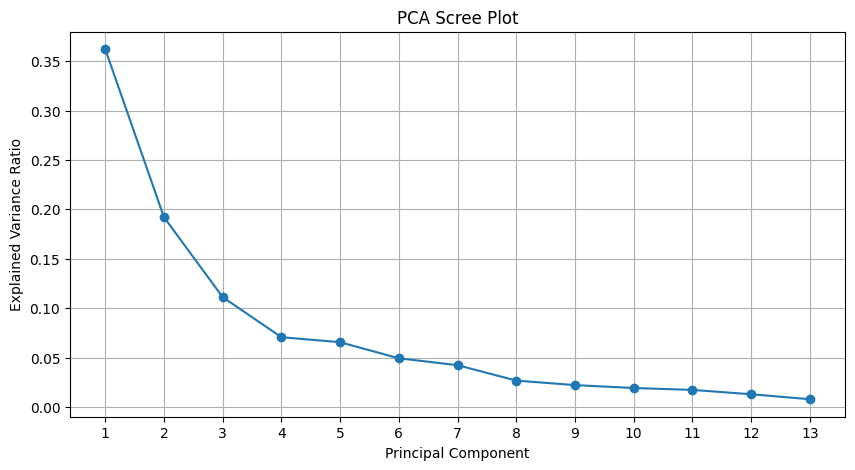

In [ ]:
# Scree Plot

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance,
    marker='o'
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Scree Plot")
plt.xticks(range(1, 14))
plt.grid(True)

plt.show()

In [ ]:
# Select first 2 principal components

pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print("Shape after PCA:", X_pca_2d.shape)

print("PC1 variance:", round(pca_2d.explained_variance_ratio_[0] * 100, 2), "%")
print("PC2 variance:", round(pca_2d.explained_variance_ratio_[1] * 100, 2), "%")
print("Total variance:", round(pca_2d.explained_variance_ratio_.sum() * 100, 2), "%")

Shape after PCA: (178, 2)
PC1 variance: 36.2 %
PC2 variance: 19.21 %
Total variance: 55.41 %


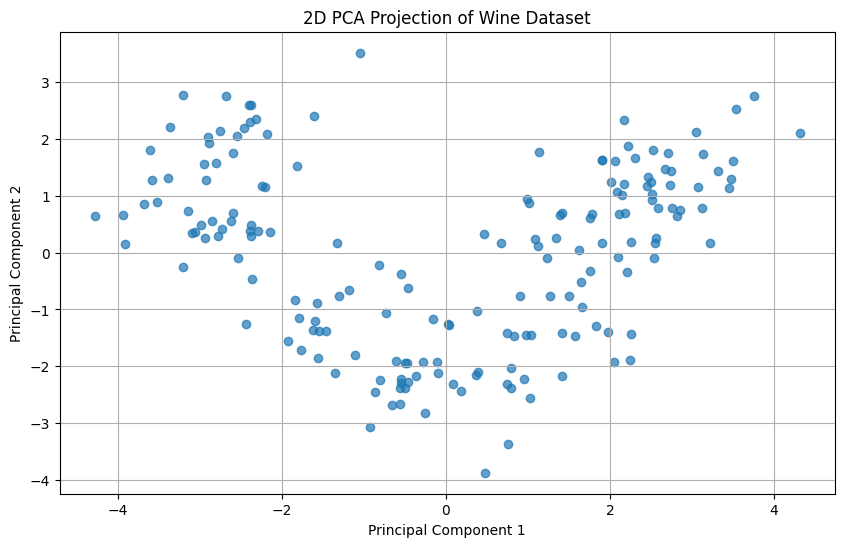

In [ ]:
# 2D PCA Visualization

plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D PCA Projection of Wine Dataset")
plt.grid(True)

plt.show()

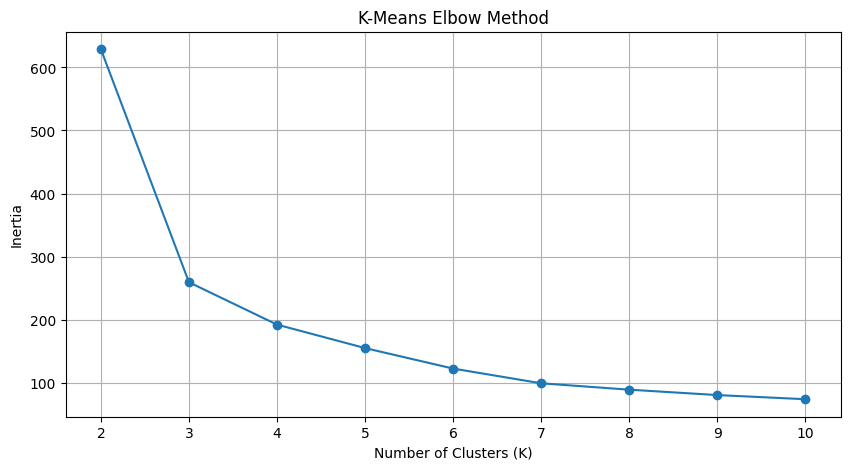

In [ ]:
# K-Means Clustering - Elbow Method

inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca_2d)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))

plt.plot(K_range, inertia, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Method")
plt.xticks(K_range)
plt.grid(True)

plt.show()

K = 2, Silhouette Score = 0.4649
K = 3, Silhouette Score = 0.5611
K = 4, Silhouette Score = 0.4914
K = 5, Silhouette Score = 0.4391
K = 6, Silhouette Score = 0.4334
K = 7, Silhouette Score = 0.4222
K = 8, Silhouette Score = 0.4072
K = 9, Silhouette Score = 0.3994
K = 10, Silhouette Score = 0.4016


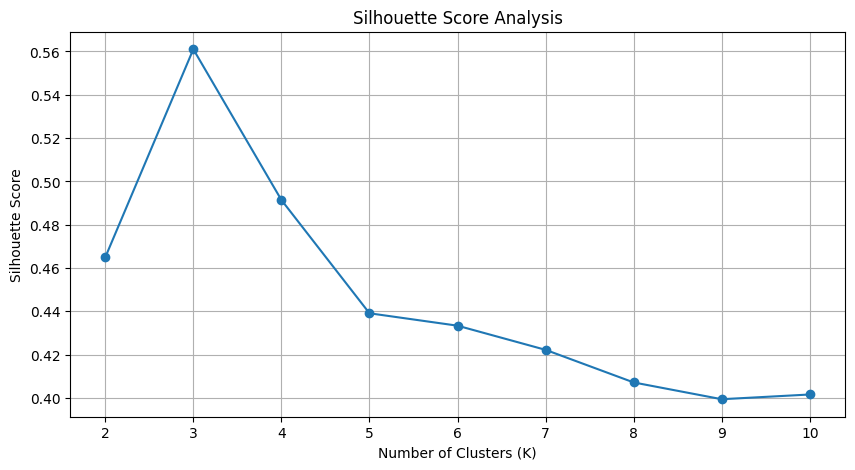

In [ ]:
# Silhouette Score Analysis

silhouette_scores = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca_2d)

    score = silhouette_score(X_pca_2d, labels)
    silhouette_scores.append(score)

# Display scores
for k, score in zip(K_range, silhouette_scores):
    print(f"K = {k}, Silhouette Score = {score:.4f}")

# Plot Silhouette Scores
plt.figure(figsize=(10, 5))

plt.plot(K_range, silhouette_scores, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score Analysis")
plt.xticks(K_range)
plt.grid(True)

plt.show()

In [ ]:
# Final K-Means Clustering with K = 3

best_k = 3

kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans_final.fit_predict(X_pca_2d)

# Add cluster labels to a DataFrame
clustered_data = pd.DataFrame(
    X_pca_2d,
    columns=["PC1", "PC2"]
)

clustered_data["Cluster"] = kmeans_labels

print("Cluster counts:")
print(clustered_data["Cluster"].value_counts().sort_index())

Cluster counts:
Cluster
0    64
1    49
2    65
Name: count, dtype: int64


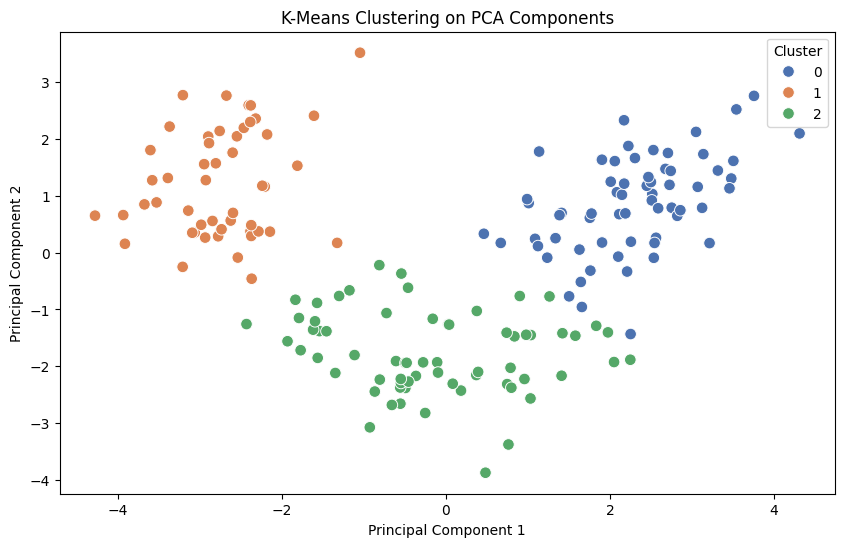

In [ ]:
# K-Means Cluster Visualization

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="Cluster",
    data=clustered_data,
    palette="deep",
    s=70
)

plt.title("K-Means Clustering on PCA Components")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")

plt.show()

In [ ]:
# DBSCAN Clustering

dbscan = DBSCAN(eps=0.8, min_samples=5)

dbscan_labels = dbscan.fit_predict(X_pca_2d)

clustered_data["DBSCAN_Cluster"] = dbscan_labels

print("DBSCAN Cluster Counts:")
print(clustered_data["DBSCAN_Cluster"].value_counts().sort_index())

DBSCAN Cluster Counts:
DBSCAN_Cluster
-1      5
 0    127
 1     46
Name: count, dtype: int64


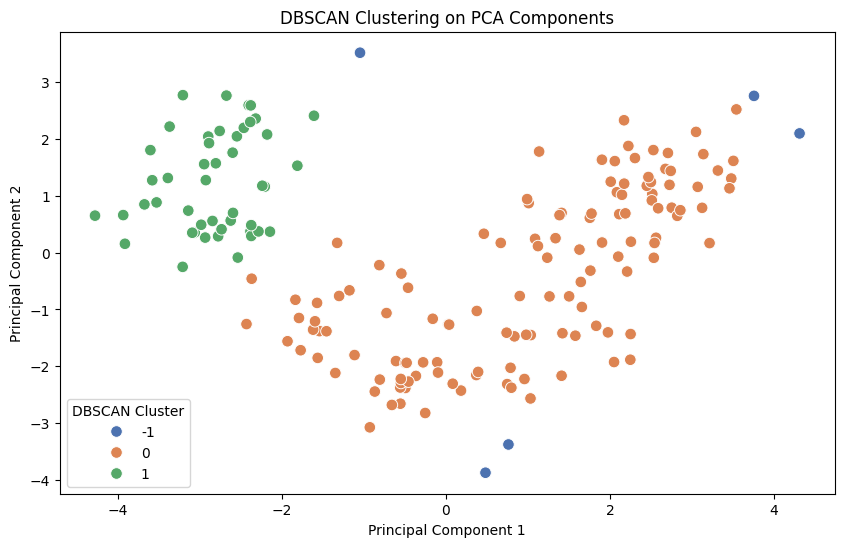

In [ ]:
# DBSCAN Cluster Visualization

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="DBSCAN_Cluster",
    data=clustered_data,
    palette="deep",
    s=70
)

plt.title("DBSCAN Clustering on PCA Components")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="DBSCAN Cluster")

plt.show()

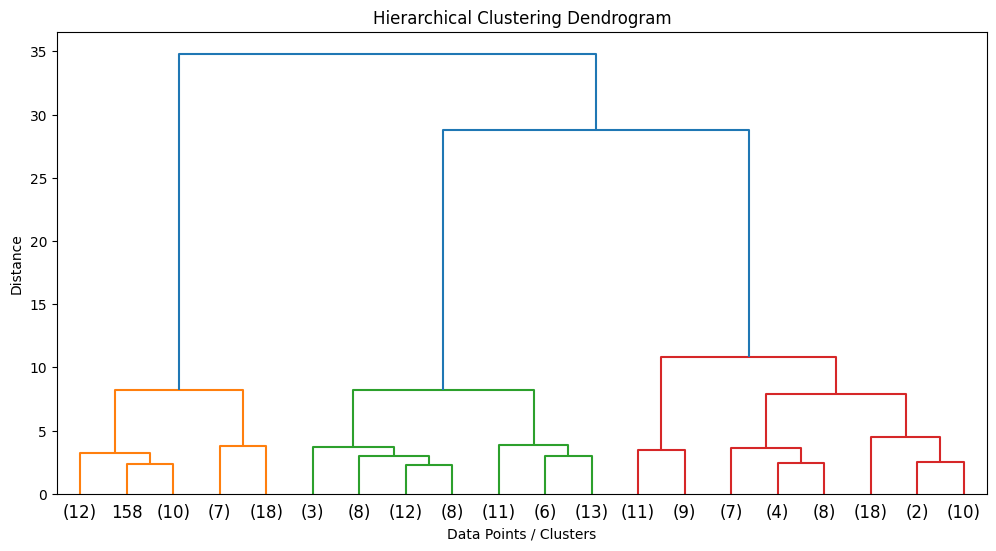

In [ ]:
# Hierarchical Clustering - Dendrogram

plt.figure(figsize=(12, 6))

linkage_matrix = linkage(X_pca_2d, method="ward")

dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=20
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points / Clusters")
plt.ylabel("Distance")

plt.show()

In [ ]:
# Hierarchical Agglomerative Clustering

hierarchical = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

hierarchical_labels = hierarchical.fit_predict(X_pca_2d)

clustered_data["Hierarchical_Cluster"] = hierarchical_labels

print("Hierarchical Cluster Counts:")
print(
    clustered_data["Hierarchical_Cluster"]
    .value_counts()
    .sort_index()
)

Hierarchical Cluster Counts:
Hierarchical_Cluster
0    69
1    48
2    61
Name: count, dtype: int64


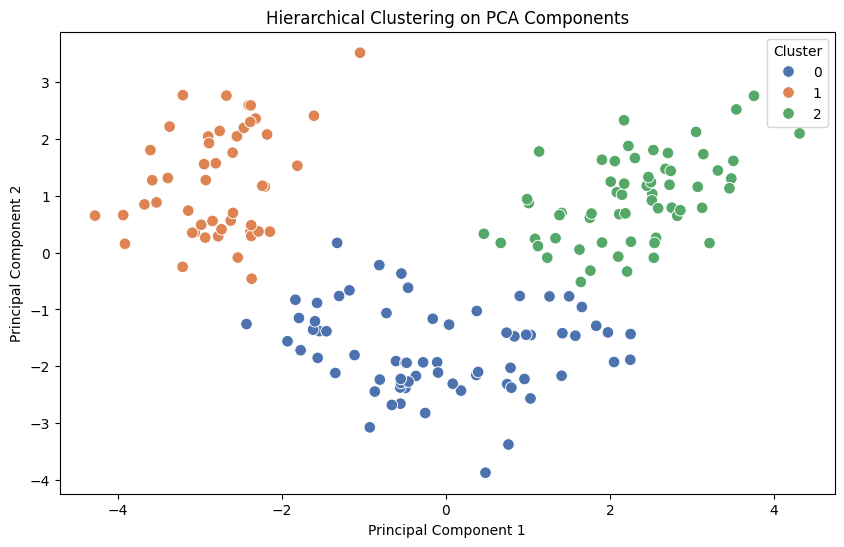

In [ ]:
# Hierarchical Clustering Visualization

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="Hierarchical_Cluster",
    data=clustered_data,
    palette="deep",
    s=70
)

plt.title("Hierarchical Clustering on PCA Components")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")

plt.show()

In [ ]:
# Final Comparison of Clustering Methods

print("===== CLUSTERING SUMMARY =====")

print("\n1. K-Means")
print("Optimal number of clusters: 3")
print("Best Silhouette Score: 0.5611")

print("\n2. DBSCAN")
print("Clusters found: 2")
print("Noise points: 5")

print("\n3. Hierarchical Clustering")
print("Number of clusters: 3")

print("\nPCA was used to reduce the 13-dimensional dataset to 2 principal components for visualization.")

===== CLUSTERING SUMMARY =====

1. K-Means
Optimal number of clusters: 3
Best Silhouette Score: 0.5611

2. DBSCAN
Clusters found: 2
Noise points: 5

3. Hierarchical Clustering
Number of clusters: 3

PCA was used to reduce the 13-dimensional dataset to 2 principal components for visualization.


In [ ]:
# Conclusion

print("""
CONCLUSION

The Wine dataset was standardized before applying dimensionality
reduction and clustering techniques.

PCA was used to reduce the dimensionality of the 13 numerical
features. The Explained Variance Ratio and Scree Plot were used
to understand the contribution of each principal component.

K-Means clustering was evaluated using the Elbow Method and
Silhouette Score. The highest Silhouette Score was obtained
for K = 3 with a score of 0.5611.

DBSCAN identified two main clusters and 5 noise points.

Hierarchical Agglomerative Clustering was also applied with
3 clusters, and a dendrogram was created to visualize the
hierarchical structure of the data.

Overall, PCA helped visualize the high-dimensional data, while
K-Means, DBSCAN, and Hierarchical Clustering revealed different
patterns and groupings within the dataset.
""")


CONCLUSION

The Wine dataset was standardized before applying dimensionality
reduction and clustering techniques.

PCA was used to reduce the dimensionality of the 13 numerical
features. The Explained Variance Ratio and Scree Plot were used
to understand the contribution of each principal component.

K-Means clustering was evaluated using the Elbow Method and
Silhouette Score. The highest Silhouette Score was obtained
for K = 3 with a score of 0.5611.

DBSCAN identified two main clusters and 5 noise points.

Hierarchical Agglomerative Clustering was also applied with
3 clusters, and a dendrogram was created to visualize the
hierarchical structure of the data.

Overall, PCA helped visualize the high-dimensional data, while
K-Means, DBSCAN, and Hierarchical Clustering revealed different
patterns and groupings within the dataset.

